In [47]:

import pandas as pd
from itertools import product

# Read the dataframe
df = pd.read_csv("/Users/surya/Desktop/riverline_takehome/dev/conversation_bundle_flat.csv")

# Helper: for each row, determine which annotation columns are notnull
def annotation_presence(row):
    return tuple(pd.notnull([row["an1"], row["an2"], row["an3"]]))

# Map: combination name -> conversation IDs with that combination
combination_ids = {}

# All combinations: (an1, an2, an3) where each is True (present) or False (missing)
combinations = list(product([False, True], repeat=3))
labels = ['an1', 'an2', 'an3']

for comb in combinations:
    # Build description for print/readability
    if any(comb):
        comb_desc = "only " + ", ".join(l for l, p in zip(labels, comb) if p) if sum(comb) == 1 else " & ".join(l for l, p in zip(labels, comb) if p)
    else:
        comb_desc = "none"
    mask = (pd.notnull(df['an1']) if comb[0] else df['an1'].isnull()) & \
           (pd.notnull(df['an2']) if comb[1] else df['an2'].isnull()) & \
           (pd.notnull(df['an3']) if comb[2] else df['an3'].isnull())
    ids = df.loc[mask, "conversation_id"].unique().tolist()
    combination_ids[comb_desc] = ids

# Print results
for k, v in combination_ids.items():
    print(f"Conversation IDs with {k}: {len(v)}")


Conversation IDs with none: 300
Conversation IDs with only an3: 100
Conversation IDs with only an2: 100
Conversation IDs with an2 & an3: 0
Conversation IDs with only an1: 100
Conversation IDs with an1 & an3: 0
Conversation IDs with an1 & an2: 0
Conversation IDs with an1 & an2 & an3: 100


In [48]:
combination_ids.keys()

dict_keys(['none', 'only an3', 'only an2', 'an2 & an3', 'only an1', 'an1 & an3', 'an1 & an2', 'an1 & an2 & an3'])

In [49]:
# Get 2 conversation IDs from each combination in combination_ids;
two_per_combination = {k: v[:2] for k, v in combination_ids.items()}
two_per_combination 

for k,v in combination_ids.items():
    if len(v) > 2:
        print(f'{k}: {v[:2]}')

none: ['00ad209e-5236-c672-860f-53bee3b366cd', '018ddf34-d2f6-ae46-76fa-33c67ae24235']
only an3: ['003d61b9-9929-0d01-78c0-72d65befe630', '007fd69e-f588-87d7-edef-6847b0ff176e']
only an2: ['022f42f7-2654-206e-c2e5-100b86c215ee', '03f02884-3f00-12b6-2300-93e089e3fec6']
only an1: ['0398595b-e02f-56a1-73e9-3788e6aba235', '04fe76b0-23de-3a1b-d545-915eec901fbc']
an1 & an2 & an3: ['00ab8e48-5dd9-3bb5-c054-216ab58c9fda', '0116e0f9-0373-5d3a-149d-7b18d3c3c579']


In [50]:

combination_ids['an1 & an2 & an3'][:10]

['00ab8e48-5dd9-3bb5-c054-216ab58c9fda',
 '0116e0f9-0373-5d3a-149d-7b18d3c3c579',
 '01d2bc92-a9d8-1c8c-3a16-3bc390f1de16',
 '0261f428-dcd8-21c5-227c-f8d0502cc8d2',
 '032101dc-a78c-9aa9-c8e2-5f92b42f1dfa',
 '051670b7-b772-dc86-433a-099a40b8ab18',
 '05739a43-4de4-af02-6b9c-81092e72bcff',
 '081f905f-2867-2616-d97a-37ee7ebcf7db',
 '0d279dd8-65e4-98e1-549d-f47998bba681',
 '0fdf1e6b-da43-39e8-de9e-5e1e45207173']

In [51]:
import pandas as pd

# Read the dataframe
df = pd.read_csv("/Users/surya/Desktop/riverline_takehome/dev/conversation_bundle_flat.csv")

# Attempt to safely extract the language from the metadata column;
# This handles cases where metadata is a string representation of a dict (e.g. JSON).
import ast

def extract_language(metadata):
    if pd.isnull(metadata):
        return None
    # Try parsing metadata as dict if it's a string; handle errors gracefully
    if isinstance(metadata, dict):
        meta = metadata
    else:
        try:
            meta = ast.literal_eval(str(metadata))
        except Exception:
            return None
    return meta.get("language")

df["language"] = df["metadata"].apply(extract_language)

# Group conversation IDs by language
language_groups = df.groupby("language")["conversation_id"].apply(list).to_dict()

for lang, conv_ids in language_groups.items():
    print(f"Language={lang!r}, Conversation IDs count: {len(conv_ids)}")

Language='english', Conversation IDs count: 250
Language='hindi', Conversation IDs count: 250
Language='hinglish', Conversation IDs count: 200


In [52]:
for lang, conv_ids in language_groups.items():
    sample_ids = conv_ids[:2]
    print(f"Language={lang!r}, 2 sample conversation IDs: {sample_ids}")

Language='english', 2 sample conversation IDs: ['02081e55-d651-39f8-dc14-17e3cbb3cb11', '0261f428-dcd8-21c5-227c-f8d0502cc8d2']
Language='hindi', 2 sample conversation IDs: ['00ab8e48-5dd9-3bb5-c054-216ab58c9fda', '00ad209e-5236-c672-860f-53bee3b366cd']
Language='hinglish', 2 sample conversation IDs: ['003d61b9-9929-0d01-78c0-72d65befe630', '007fd69e-f588-87d7-edef-6847b0ff176e']


In [53]:
import sys
sys.path.append("..")

from visualise_conv import show_conversation

an3_samples= ['003d61b9-9929-0d01-78c0-72d65befe630', '007fd69e-f588-87d7-edef-6847b0ff176e']
an2_samples= ['022f42f7-2654-206e-c2e5-100b86c215ee', '03f02884-3f00-12b6-2300-93e089e3fec6']
an1_samples= ['0398595b-e02f-56a1-73e9-3788e6aba235', '04fe76b0-23de-3a1b-d545-915eec901fbc']
an123_samples=  ['00ab8e48-5dd9-3bb5-c054-216ab58c9fda',
 '0116e0f9-0373-5d3a-149d-7b18d3c3c579',
 '01d2bc92-a9d8-1c8c-3a16-3bc390f1de16',
 '0261f428-dcd8-21c5-227c-f8d0502cc8d2',
 '032101dc-a78c-9aa9-c8e2-5f92b42f1dfa',
 '051670b7-b772-dc86-433a-099a40b8ab18',
 '05739a43-4de4-af02-6b9c-81092e72bcff',
 '081f905f-2867-2616-d97a-37ee7ebcf7db',
 '0d279dd8-65e4-98e1-549d-f47998bba681',
 '0fdf1e6b-da43-39e8-de9e-5e1e45207173']

sample = an123_samples[7]
# Example: show a conversation (replace conversation_id as needed)
show_conversation(sample)

language,english
zone,north
dpd,40
pos,35000
tos,40250
settlement_offered,31500
total_turns,10
payment_received,True
days_to_payment,19
payment_amount,8855
expected_amount,10000


In [54]:
# --- AgentEvaluator: run on all production logs, build per-conversation table ---
import ast
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

DEV = Path(".").resolve()
REPO = DEV.parent
PS = REPO / "problem_statement"
sys.path.insert(0, str(PS))

from eval_takehome import AgentEvaluator, RULES  # noqa: E402

LOG_PATH = PS / "data" / "production_logs.jsonl"
FLAT_CSV = DEV / "conversation_bundle_flat.csv"


def read_jsonl(path: Path):
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                yield json.loads(line)


def _language_from_metadata(metadata) -> str | None:
    if pd.isna(metadata):
        return None
    if isinstance(metadata, dict):
        return metadata.get("language")
    try:
        return ast.literal_eval(str(metadata)).get("language")
    except Exception:
        return None


evaluator = AgentEvaluator()
rows: list[dict] = []
viol_rows: list[dict] = []

for conv in read_jsonl(LOG_PATH):
    cid = conv["conversation_id"]
    res = evaluator.evaluate(conv)
    rule_counts: dict[str, int] = {}
    for v in res["violations"]:
        r = v["rule"]
        rule_counts[r] = rule_counts.get(r, 0) + 1
        viol_rows.append({"conversation_id": cid, **v})
    row = {
        "conversation_id": cid,
        "quality_score": res["quality_score"],
        "risk_score": res["risk_score"],
        "n_violations": len(res["violations"]),
    }
    for rule_id in RULES:
        row[f"n_{rule_id}"] = rule_counts.get(rule_id, 0)
    rows.append(row)

eval_df = pd.DataFrame(rows)
viol_df = pd.DataFrame(viol_rows) if viol_rows else pd.DataFrame()

# Language from flat bundle (same CSV as earlier cells)
_flat = pd.read_csv(FLAT_CSV, usecols=["conversation_id", "metadata"])
_flat["language"] = _flat["metadata"].apply(_language_from_metadata)
eval_df = eval_df.merge(_flat[["conversation_id", "language"]], on="conversation_id", how="left")

print(f"Evaluated {len(eval_df)} conversations from {LOG_PATH}")
print("\nScore summary:")
print(eval_df[["quality_score", "risk_score", "n_violations"]].describe().T)
print("\nViolations by rule (total event count):")
_rule_totals = {rid: int(eval_df[f"n_{rid}"].sum()) for rid in RULES}
for rid, cnt in sorted(_rule_totals.items(), key=lambda x: -x[1]):
    if cnt:
        print(f"  {rid}: {cnt}")

display(eval_df.sort_values("risk_score", ascending=False).head(15))
eval_df.head()


Evaluated 700 conversations from /Users/surya/Desktop/riverline_takehome/problem_statement/data/production_logs.jsonl

Score summary:
               count      mean       std   min   25%   50%    75%   max
quality_score  700.0  0.407114  0.215142  0.15  0.15  0.49  0.600   1.0
risk_score     700.0  0.537264  0.261300  0.00  0.40  0.40  0.645   1.0
n_violations   700.0  2.952857  2.552298  0.00  1.00  2.00  4.000  11.0

Violations by rule (total event count):
  QLT_REPETITIVE_RESPONSE_LOOP: 956
  AMT_SETTLEMENT_AMOUNT_OUT_OF_BOUNDS: 460
  INV_EXIT_STATE_NOT_FINAL: 441
  TR_INVALID_STATE_TRANSITION: 169
  TR_BACKWARD_TRANSITION_NOT_ALLOWED: 41


,conversation_id,quality_score,risk_score,n_violations,n_TR_INVALID_STATE_TRANSITION,n_TR_BACKWARD_TRANSITION_NOT_ALLOWED,n_TR_BACKWARD_EXCEPTION_MISUSED,n_INV_EXIT_STATE_NOT_FINAL,n_ACT_REQUEST_SETTLEMENT_AMOUNT_INVALID_CONTEXT,n_ACT_CONFIRM_PAYMENT_INVALID_CONTEXT,n_AMT_POS_GREATER_THAN_TOS,n_AMT_SETTLEMENT_AMOUNT_OUT_OF_BOUNDS,n_QLT_REPETITIVE_RESPONSE_LOOP,language
119,0261f428-dcd8-21c5-227c-f8d0502cc8d2,0.15,1.0,3,1,0,0,2,0,0,0,0,0,english
141,bad44e7e-5ffc-6dd3-2f66-bc55b2cff7f6,0.15,1.0,7,2,0,0,5,0,0,0,0,0,english
131,4fe9f8fc-7adc-ebec-1fe1-1a43f8307243,0.15,1.0,7,2,0,0,5,0,0,0,0,0,english
132,f830b6cb-d001-af00-ad4c-bb0d568921e8,0.15,1.0,3,1,0,0,2,0,0,0,0,0,english
133,1040a60b-cd36-1cc4-a43d-bc557e8cc102,0.15,1.0,4,1,0,0,3,0,0,0,0,0,english
134,800d98e4-ab54-4fd7-8dec-cc9dd7911ab5,0.15,1.0,3,1,0,0,2,0,0,0,0,0,english
135,cd5dad45-eed4-31c5-6aa7-a09c7c192fd3,0.15,1.0,3,1,0,0,2,0,0,0,0,0,english
136,b225a421-85f2-93da-c2bf-e8da5a3238fc,0.15,1.0,6,2,0,0,4,0,0,0,0,0,english
137,5d1f6d7a-6f5d-8b19-77d9-c7edcd55b5bb,0.15,1.0,3,1,0,0,2,0,0,0,0,0,english
138,84c70609-895d-a8dd-e013-61c9bffc93cd,0.15,1.0,4,1,0,0,3,0,0,0,0,0,english


,conversation_id,quality_score,risk_score,n_violations,n_TR_INVALID_STATE_TRANSITION,n_TR_BACKWARD_TRANSITION_NOT_ALLOWED,n_TR_BACKWARD_EXCEPTION_MISUSED,n_INV_EXIT_STATE_NOT_FINAL,n_ACT_REQUEST_SETTLEMENT_AMOUNT_INVALID_CONTEXT,n_ACT_CONFIRM_PAYMENT_INVALID_CONTEXT,n_AMT_POS_GREATER_THAN_TOS,n_AMT_SETTLEMENT_AMOUNT_OUT_OF_BOUNDS,n_QLT_REPETITIVE_RESPONSE_LOOP,language
0,192f029c-2626-7e25-7fee-3fff275530b7,0.60,0.40,1,0,0,0,0,0,0,0,1,0,english
1,5e21f706-117e-4ef1-7e9b-7c3dc135123c,0.60,0.40,1,0,0,0,0,0,0,0,1,0,english
2,66263e7c-a4b2-c28a-7093-285797711127,0.60,0.40,1,0,0,0,0,0,0,0,1,0,english
3,eafa2fdc-e973-3ef8-7af9-09c6a59012a4,0.60,0.40,1,0,0,0,0,0,0,0,1,0,english
4,18318619-8cf2-3e5d-1e1a-62d091808f9c,0.72,0.07,2,0,0,0,0,0,0,0,0,2,english


In [55]:
# ── Generate eval JSONL (versioned) ─────────────────────────────────────────
# Run AgentEvaluator on all production logs and save to dev/eval_v<N>.jsonl
# Increment EVAL_VERSION each time you want a fresh snapshot.

import json
import sys
from pathlib import Path

DEV_DIR = Path(".").resolve()
PS_DIR  = DEV_DIR.parent / "problem_statement"
sys.path.insert(0, str(PS_DIR))

from eval_takehome import AgentEvaluator  # noqa: E402

EVAL_VERSION = 1                                        # bump for each new run
EVAL_OUT = DEV_DIR / f"eval_v{EVAL_VERSION}.jsonl"

def _iter_jsonl(path: Path):
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                yield json.loads(line)

evaluator = AgentEvaluator()
n_written = 0
with open(EVAL_OUT, "w", encoding="utf-8") as out_f:
    for conv in _iter_jsonl(PS_DIR / "data" / "production_logs.jsonl"):
        result = evaluator.evaluate(conv)
        record = {
            "conversation_id": conv["conversation_id"],
            "quality_score":   result["quality_score"],
            "risk_score":      result["risk_score"],
            "violations":      result["violations"],
        }
        out_f.write(json.dumps(record, ensure_ascii=False) + "\n")
        n_written += 1

print(f"Wrote {n_written} records → {EVAL_OUT}")


Wrote 700 records → /Users/surya/Desktop/riverline_takehome/dev/eval_v1.jsonl


In [56]:
import collections

# Read the eval file and parse violations
violation_counter = collections.Counter()
violation_name_map = {}
violation_name2conv_id_list = {}

with open(EVAL_OUT, encoding='utf-8') as f:
    for line in f:
        if not line.strip():
            continue
        rec = json.loads(line)
        for v in rec.get("violations", []):
            rule_id = v.get("rule")
            violation_counter[rule_id] += 1
            # Get the expanded name if available (assuming explanation gives name)
            violation_name_map[rule_id] = v.get("explanation", "")
            violation_name2conv_id_list[rule_id] = violation_name2conv_id_list.get(rule_id, []) + [rec["conversation_id"]]

total_violations = sum(violation_counter.values())
print(f"Total number of violations: {total_violations}\n")

print("Frequency of violation types:")
for rule, freq in violation_counter.most_common():
    name = violation_name_map.get(rule, "")
    print(f"  {rule}: {freq}  ->  {name[:90].replace('\n',' ')}{'...' if len(name) > 90 else ''}")

# If you want a dict mapping violation type to their name (shortened)
violation_type_to_name = {rule: (name[:90] + ('...' if len(name) > 90 else '')) for rule, name in violation_name_map.items()}

Total number of violations: 2067

Frequency of violation types:
  QLT_REPETITIVE_RESPONSE_LOOP: 956  ->  Bot repeated identical message at turn 14 (previous identical turn: 13).
  AMT_SETTLEMENT_AMOUNT_OUT_OF_BOUNDS: 460  ->  settlement_offered=234000 not within [POS=250000, TOS=287500]; settlement amount must lie ...
  INV_EXIT_STATE_NOT_FINAL: 441  ->  Bot sent message at turn 10 after entering terminal state at turn 5; no further automated ...
  TR_INVALID_STATE_TRANSITION: 169  ->  Transition escalated -> escalated is not permitted by the spec transition matrix.
  TR_BACKWARD_TRANSITION_NOT_ALLOWED: 41  ->  Illegal backward transition intent_asked -> amount_sent; only settlement_explained/amount_...


In [ ]:
violation_name2conv_id_list

for k,v in violation_name2conv_id_list.items():
    print(f"{k}: {len(v)}")


In [22]:
df = pd.read_csv(csv_path)
df.columns

Index(['conversation_id', 'n_annotations', 'metadata', 'prod_log', 'outcome',
       'an1', 'an2', 'an3'],
      dtype='str')

In [26]:
df.all_annotations

0      [{'conversation_id': '003d61b9-9929-0d01-78c0-72d65befe630', 'quality_score': 0.1, 'failure_points': [{'turn': 6, 'category': 'repetition', 'severity': 0.8,...
1      [{'conversation_id': '007fd69e-f588-87d7-edef-6847b0ff176e', 'quality_score': 0.1, 'failure_points': [{'turn': 1, 'category': 'missed_escalation', 'severity...
2      [{'conversation_id': '00ab8e48-5dd9-3bb5-c054-216ab58c9fda', 'quality_score': 0.1, 'failure_points': [{'turn': 5, 'category': 'misclassification', 'severity...
3                                                                                                                                                                   []
4      [{'conversation_id': '00d924eb-6b0f-4f64-5df9-24414f511088', 'quality_score': 0.1, 'failure_points': [{'turn': 4, 'category': 'repetition', 'severity': 0.8,...
                                                                                    ...                                                                              

In [57]:
import pandas as pd
import ast

csv_path = "/Users/surya/Desktop/riverline_takehome/dev/conversation_bundle_flat.csv"

df = pd.read_csv(csv_path)

# Helper: Safely parse a string to dict (ast for Python dicts, fallback to JSON)
def safe_parsedict(val):
    if pd.isna(val) or val is None:
        return {}
    if isinstance(val, dict):
        return val
    try:
        return ast.literal_eval(val)
    except Exception:
        try:
            import json
            return json.loads(val)
        except Exception:
            return {}

# Parse all annotations ('an1', 'an2', 'an3') into a single list per row, skip if cell is None
ann_cols = [col for col in df.columns if col.startswith("an")]
def collect_ann(row):
    result = []
    for c in ann_cols:
        raw = row[c] if c in row and row[c] is not None else None
        if raw is None or pd.isna(raw):
            continue  # Ignore cells that are None or NaN
        parsed = safe_parsedict(raw)
        if parsed and isinstance(parsed, dict) and len(parsed) > 0:
            result.append(parsed)
    return result

df['all_annotations'] = df.apply(collect_ann, axis=1)

# Gather all unique annotators -- if _annotator key is present in any parsed annotation
all_annotators = set()
for ann_list in df['all_annotations']:
    for ann in ann_list:
        if isinstance(ann, dict) and '_annotator' in ann:
            all_annotators.add(ann['_annotator'])
if not all_annotators:
    all_annotators = {'unknown_annotator'}

# Summaries: {annotator: {category: [{conv_id, turn, severity, note}, ...], risk_flags_label: [ (conv_id, flag), ...] }}
summaries = {annotator: {} for annotator in all_annotators}

for idx, row in df.iterrows():
    conv_id = row['conversation_id'] if 'conversation_id' in row else None
    ann_list = row['all_annotations']
    for ann in ann_list:
        annotator = ann.get('_annotator', next(iter(all_annotators)))
        # Failure points
        fps = ann.get('failure_points', [])
        for fp in fps:
            cat = fp.get('category', 'uncategorized')
            entry = {
                'conv_id': conv_id,
                'turn': fp.get('turn', None),
                'severity': fp.get('severity'),
                'note': fp.get('note'),
            }
            summaries.setdefault(annotator, {}).setdefault(cat, []).append(entry)
        # Risk flags
        risk_flags = ann.get('risk_flags', [])
        if risk_flags:
            summaries.setdefault(annotator, {}).setdefault('risk_flags_label', []).extend([(conv_id, rf) for rf in risk_flags])



In [ ]:
!pip install matplotlib


Annotator: annotator_1
  misclassification: 86 
  repetition: 420 
  state_machine_error: 248 
  context_loss: 157 
  amount_error: 96 
  ignored_hardship: 125 
  wrong_information: 88 
  missed_escalation: 97 
  tone_mismatch: 12 
  inappropriate_pressure: 83 
  other: 120 
  stop_request_missed: 14 
  language_error: 4 
  compliance_concern: 8 

Annotator: annotator_3
  repetition: 635 
  context_loss: 142 
  missed_escalation: 31 
  tone_mismatch: 45 
  state_machine_error: 24 
  wrong_information: 13 
  amount_error: 8 
  stop_request_missed: 19 
  escalation_missed: 3 
  inappropriate_pressure: 21 
  misclassification: 8 
  ignored_hardship: 1 
  other: 8 
  tone_inappropriate: 18 

Annotator: annotator_2
  repetition: 192 
  context_loss: 36 
  ignored_hardship: 70 
  tone_mismatch: 84 
  missed_escalation: 32 
  stop_request_missed: 26 
  wrong_information: 20 
  misclassification: 7 
  amount_error: 12 
  other: 3 
  inappropriate_pressure: 16 
  escalation_missed: 2 
  state_

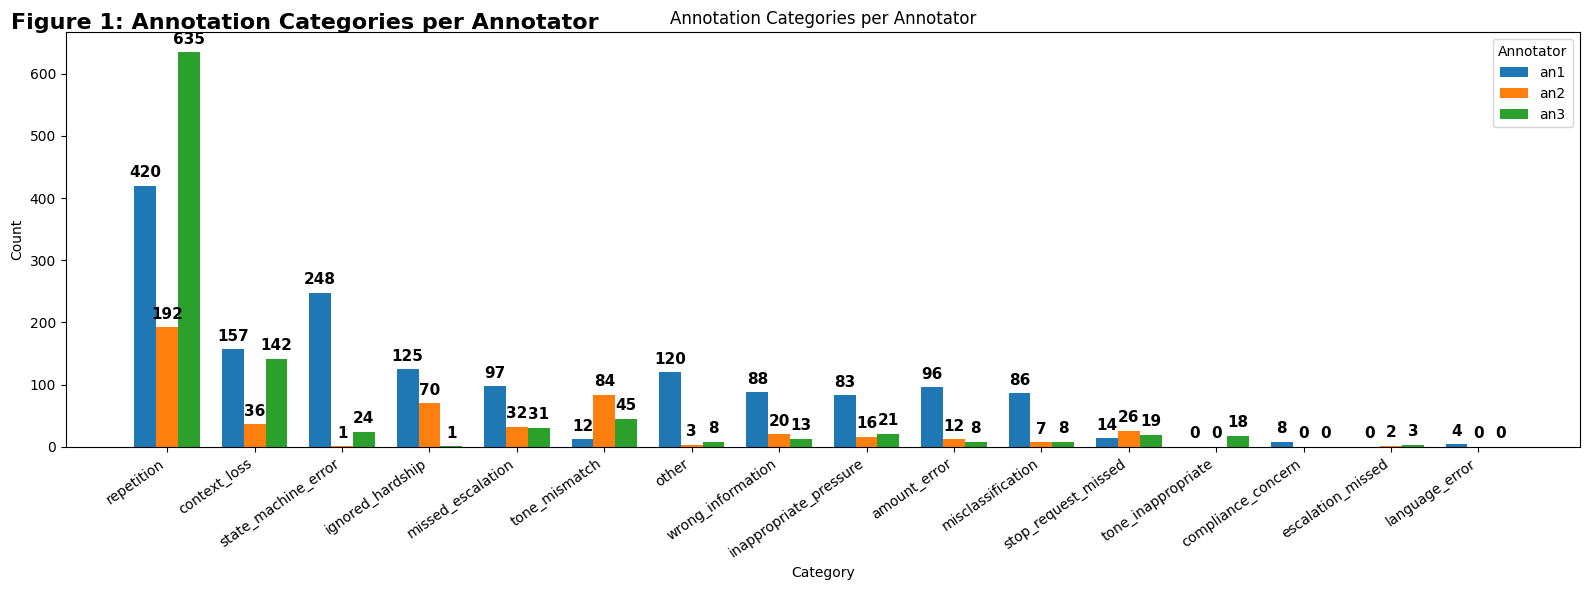

In [58]:
import matplotlib.pyplot as plt
import numpy as np

# Print summary for each annotator

annotator_category_counts = {"annotator_1": {}, "annotator_2": {}, "annotator_3": {}}
for annotator, by_cat in summaries.items():
    print(f"\nAnnotator: {annotator}")
    for cat, items in by_cat.items():
        if cat == 'risk_flags_label':
            pass
        else:
            print(f"  {cat}: {len(items)} ")
            annotator_category_counts[annotator][cat] = len(items)

# 1. Get all categories & accumulate total for sorting
all_cats = set()
for counts in annotator_category_counts.values():
    all_cats.update(counts.keys())
cat_totals = {cat: 0 for cat in all_cats}
for annot_counts in annotator_category_counts.values():
    for cat, count in annot_counts.items():
        cat_totals[cat] += count
# Sort categories by cumulative (descending), then name
sorted_cats = sorted(cat_totals, key=lambda c: (-cat_totals[c], c))

# 2. Build matrix of counts aligned by sorted categories
an_keys = ['annotator_1', 'annotator_2', 'annotator_3']
cat_counts_matrix = []
for annot in an_keys:
    annot_counts = annotator_category_counts.get(annot, {})
    cat_counts_matrix.append([annot_counts.get(cat, 0) for cat in sorted_cats])

cat_counts_matrix = np.array(cat_counts_matrix)  # shape: (3, num_cats)

# 3. Plot grouped bar chart and add freq num at top of each bar
fig, ax = plt.subplots(figsize=(16, 6))

x = np.arange(len(sorted_cats))
width = 0.25
colors = ['tab:blue', 'tab:orange', 'tab:green']
labels = ['an1', 'an2', 'an3']

fig_num = 1
fig_text = f"Figure {fig_num}: Annotation Categories per Annotator"
plt.figtext(0.01, 0.97, fig_text, fontsize=16, ha='left', va='top', weight='bold')

bars_group = []
for i, (an, color, label) in enumerate(zip(an_keys, colors, labels)):
    bars = ax.bar(x + i*width - width, cat_counts_matrix[i], width, label=label, color=color)
    bars_group.append(bars)
    # Annotate each bar with its frequency
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{int(height)}",
            xy=(bar.get_x() + bar.get_width()/2, height),
            xytext=(0, 4),  # Offset text a little above bar
            textcoords="offset points",
            ha='center', va='bottom',
            fontsize=11, fontweight='bold'
        )

ax.set_xticks(x)
ax.set_xticklabels(sorted_cats, rotation=35, ha='right')
ax.set_ylabel('Count')
ax.set_xlabel('Category')
ax.set_title('Annotation Categories per Annotator')
ax.legend(title='Annotator')
plt.tight_layout()
plt.show()


Annotator: annotator_1
  misclassification: 48 
  repetition: 179 
  state_machine_error: 123 
  context_loss: 77 
  amount_error: 54 
  ignored_hardship: 65 
  wrong_information: 46 
  missed_escalation: 50 
  tone_mismatch: 6 
  inappropriate_pressure: 47 
  other: 60 
  stop_request_missed: 8 
  language_error: 1 
  compliance_concern: 3 

Annotator: annotator_3
  repetition: 307 
  context_loss: 77 
  missed_escalation: 14 
  tone_mismatch: 17 
  state_machine_error: 6 
  wrong_information: 3 
  amount_error: 3 
  stop_request_missed: 17 
  escalation_missed: 3 
  inappropriate_pressure: 16 
  misclassification: 4 
  ignored_hardship: 1 
  other: 1 
  tone_inappropriate: 10 

Annotator: annotator_2
  repetition: 109 
  context_loss: 21 
  ignored_hardship: 30 
  tone_mismatch: 39 
  missed_escalation: 14 
  stop_request_missed: 13 
  wrong_information: 7 
  misclassification: 4 
  amount_error: 7 
  other: 3 
  inappropriate_pressure: 8 
  escalation_missed: 0 
  state_machine_err

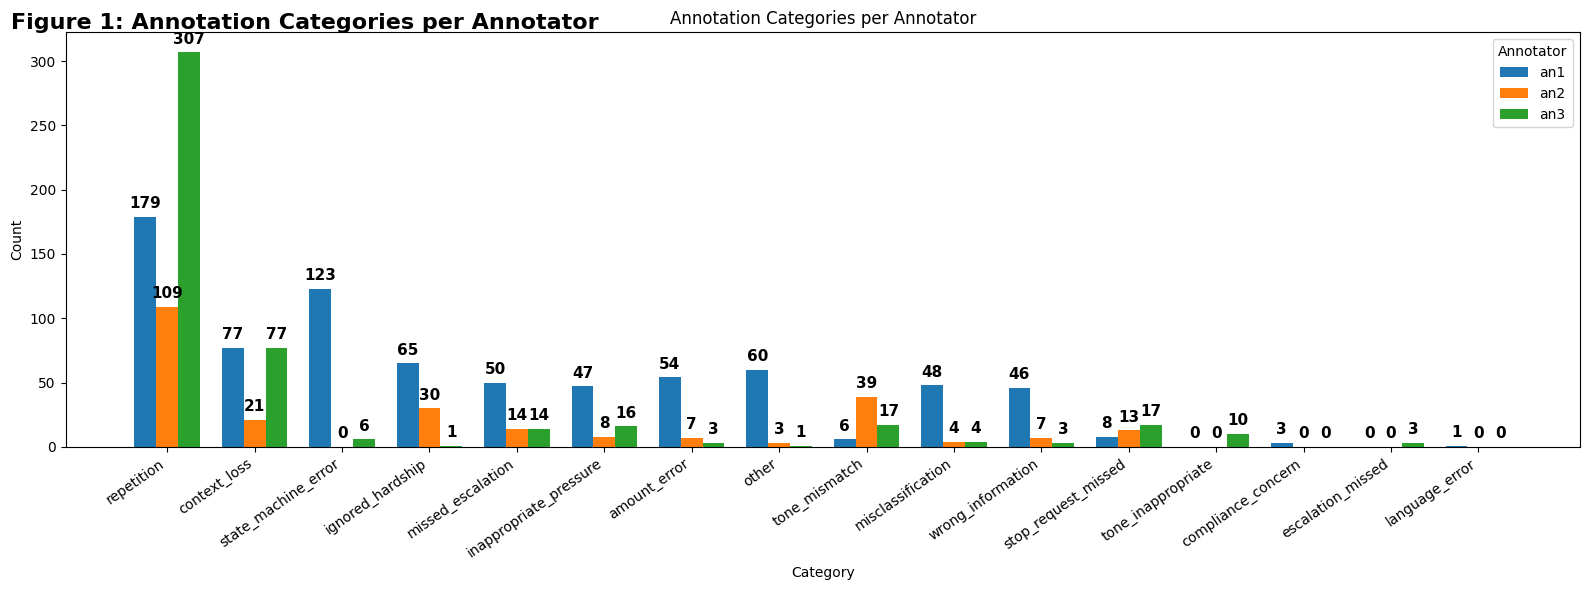

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Print summary for each annotator

# Exclude conversation_ids that are present in all three annotators for category counts
# 1. Find conversation_ids present in all three annotators

# Get conversation_ids present in all three annotators by checking n_annotations == 3
common_convs = set(df.loc[df["n_annotations"] == 3, "conversation_id"])
filtered_summaries = {annotator: {} for annotator in all_annotators}

for annotator, by_cat in summaries.items():
    for cat, items in by_cat.items():
        if cat == 'risk_flags_label':
            continue
        filtered_items = [item for item in items if item['conv_id'] in common_convs]
        filtered_summaries[annotator][cat] = filtered_items



annotator_category_counts = {"annotator_1": {}, "annotator_2": {}, "annotator_3": {}}
for annotator, by_cat in filtered_summaries.items():
    print(f"\nAnnotator: {annotator}")
    for cat, items in by_cat.items():
        if cat == 'risk_flags_label':
            pass
        else:
            print(f"  {cat}: {len(items)} ")
            annotator_category_counts[annotator][cat] = len(items)



# 1. Get all categories & accumulate total for sorting
all_cats = set()
for counts in annotator_category_counts.values():
    all_cats.update(counts.keys())
cat_totals = {cat: 0 for cat in all_cats}
for annot_counts in annotator_category_counts.values():
    for cat, count in annot_counts.items():
        cat_totals[cat] += count
# Sort categories by cumulative (descending), then name
sorted_cats = sorted(cat_totals, key=lambda c: (-cat_totals[c], c))

# 2. Build matrix of counts aligned by sorted categories
an_keys = ['annotator_1', 'annotator_2', 'annotator_3']
cat_counts_matrix = []
for annot in an_keys:
    annot_counts = annotator_category_counts.get(annot, {})
    cat_counts_matrix.append([annot_counts.get(cat, 0) for cat in sorted_cats])

cat_counts_matrix = np.array(cat_counts_matrix)  # shape: (3, num_cats)

# 3. Plot grouped bar chart and add freq num at top of each bar
fig, ax = plt.subplots(figsize=(16, 6))

x = np.arange(len(sorted_cats))
width = 0.25
colors = ['tab:blue', 'tab:orange', 'tab:green']
labels = ['an1', 'an2', 'an3']

fig_num = 1
fig_text = f"Figure {fig_num}: Annotation Categories per Annotator"
plt.figtext(0.01, 0.97, fig_text, fontsize=16, ha='left', va='top', weight='bold')

bars_group = []
for i, (an, color, label) in enumerate(zip(an_keys, colors, labels)):
    bars = ax.bar(x + i*width - width, cat_counts_matrix[i], width, label=label, color=color)
    bars_group.append(bars)
    # Annotate each bar with its frequency
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{int(height)}",
            xy=(bar.get_x() + bar.get_width()/2, height),
            xytext=(0, 4),  # Offset text a little above bar
            textcoords="offset points",
            ha='center', va='bottom',
            fontsize=11, fontweight='bold'
        )

ax.set_xticks(x)
ax.set_xticklabels(sorted_cats, rotation=35, ha='right')
ax.set_ylabel('Count')
ax.set_xlabel('Category')
ax.set_title('Annotation Categories per Annotator')
ax.legend(title='Annotator')
plt.tight_layout()
plt.show()

In [60]:
# ── Test: visualise one conversation with evaluator column ───────────────────
# Requires: cell above (EVAL_OUT written) + cell 6 (show_conversation imported)
EVAL_FILE = str(EVAL_OUT)   # e.g. dev/eval_v1.jsonl

# Pick a triple-annotated sample with known violations (repetition loop)
test_id = "00ab8e48-5dd9-3bb5-c054-216ab58c9fda"

show_conversation(test_id, eval_jsonl_file=EVAL_FILE)

language,hindi
zone,north
dpd,65
pos,120000
tos,138000
settlement_offered,
total_turns,9
payment_received,False
days_to_payment,
payment_amount,
expected_amount,10000


In [ ]:
# --- Broader results: outcomes × evaluator, language, rule mix ---
# Run the evaluation cell above first (defines eval_df, viol_df, read_jsonl, PS).
from IPython.display import display

OUTCOMES_PATH = PS / "data" / "outcomes.jsonl"

outcomes_df = pd.DataFrame(list(read_jsonl(OUTCOMES_PATH)))
merged = eval_df.merge(outcomes_df, on="conversation_id", how="left", suffixes=("", "_outcome"))

# Normalize bool columns for grouping (JSON may be bool or missing)
for c in ["borrower_complained", "regulatory_flag", "payment_received"]:
    if c in merged.columns:
        merged[c] = merged[c].fillna(False).astype(bool)

print("Mean scores by outcome flags")
display(
    merged.groupby("borrower_complained", dropna=False)[["quality_score", "risk_score", "n_violations"]]
    .mean()
    .round(3)
)
display(
    merged.groupby("regulatory_flag", dropna=False)[["quality_score", "risk_score", "n_violations"]]
    .mean()
    .round(3)
)
display(
    merged.groupby("payment_received", dropna=False)[["quality_score", "risk_score", "n_violations"]]
    .mean()
    .round(3)
)

print("\nBy language (from bundle metadata)")
_lang = (
    merged.groupby("language", dropna=False)[["quality_score", "risk_score", "n_violations"]]
    .agg(["mean", "median", "count"])
    .round(3)
)
display(_lang)

# Risk quartiles vs complaint / regulatory rate
# Fix ValueError: Bin labels must be one fewer than the number of bin edges (can happen if there are duplicate edges after `qcut`)
# Instead of fixed labels, let qcut assign default labels and then rename if desired
try:
    merged["risk_quartile"] = pd.qcut(merged["risk_score"], q=4, duplicates="drop")
except ValueError as e:
    print(f"qcut failed: {e}")
    # Fallback: assign everything to a single quartile, or skip the quartile grouping
    merged["risk_quartile"] = "all"
else:
    # Optionally assign names to quartiles if there are exactly 4 bins
    n_quart = merged["risk_quartile"].nunique(dropna=True)
    if n_quart == 4:
        merged["risk_quartile"] = pd.qcut(merged["risk_score"], q=4, labels=["Q1_low", "Q2", "Q3", "Q4_high"], duplicates="drop")
    # Otherwise, keep the Interval labels

print("\nComplaint / regulatory rate by risk quartile")
_q = merged.groupby("risk_quartile", observed=True).agg(
    n=("conversation_id", "count"),
    complained_rate=("borrower_complained", "mean"),
    regulatory_rate=("regulatory_flag", "mean"),
    mean_quality=("quality_score", "mean"),
    mean_risk=("risk_score", "mean"),
)
display(_q.round(3))

# Any high-severity structural flags
merged["any_INV"] = (merged["n_INV_EXIT_STATE_NOT_FINAL"] > 0).astype(int)
merged["any_TR_invalid"] = (merged["n_TR_INVALID_STATE_TRANSITION"] > 0).astype(int)
print("\nComplaint rate when INV_EXIT fires vs not")
display(
    merged.groupby("any_INV")["borrower_complained"].agg(["mean", "count"]).round(3)
)

print("\nPer-rule violation row counts (exploded); use for spot-checks")
if len(viol_df):
    display(viol_df["rule"].value_counts().to_frame("n_rows"))
    display(viol_df.groupby("rule")["severity"].describe().round(3).T)
